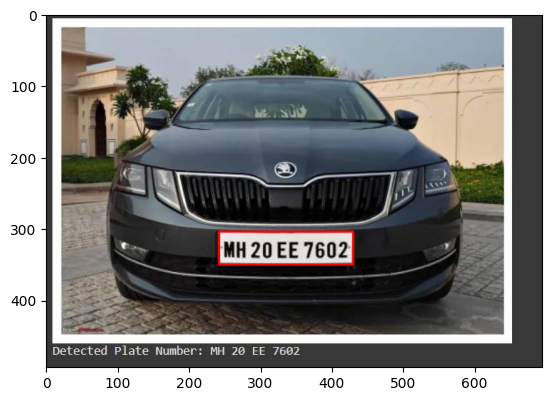

In [ ]:
# Import libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read the original image
img_original = cv.imread('images/car.jpeg')

# Create a copy of original image
img = img_original.copy()

# Convert the image from BGR to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply binary inverse thresholding 
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

# Find all contours in the thresholded image
contours, _ = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_NONE)

for c in contours:
    # Compute the area of the current contour
    area = cv.contourArea(c)

    # Ignore contours that are too small or too large to be a plate
    if area < 5000 or area > 12000:
        continue

    # Compute epsilon value for polygon approximation
    epsilon = 0.01 * cv.arcLength(c, True)

    # Approximate the contour to a simpler polygon
    approximations = cv.approxPolyDP(c, epsilon, True)

    # # Check whether the detected shape has 4 corners, because the license plate is expected to be rectangular
    if len(approximations) == 4:
         # Get the bounding rectangle of this 4-corner region as a possible license plate candidate
        x, y, w, h = cv.boundingRect(approximations)

# Create a copy of original image
img2 = img_original.copy()

# Draw a red rectangle around the detected plate region
cv.rectangle(img2, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
# Display image
plt.imshow(img2[..., ::-1])

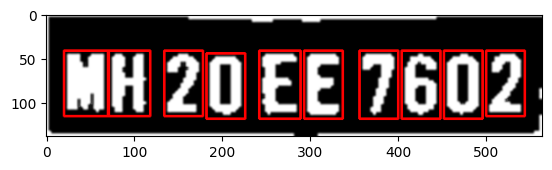

In [94]:
# Crop the detected plate region from the thresholded image
plate = thresh[y:y+h, x:x+w]

# Resize the plate image to make characters larger and easier to process
plate = cv.resize(plate, (0, 0), fx=3, fy=3, interpolation=cv.INTER_CUBIC)

# Apply Gaussian blur to reduce noise and smooth the image
blur = cv.GaussianBlur(plate, (3,3), 0)

# Create a rectangular kernel for morphological operations
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))

# Apply morphological closing to fill small gaps inside characters
close = cv.morphologyEx(blur, cv.MORPH_CLOSE, kernel)

# Find external contours in the dilated image
contours_alphabet, _ = cv.findContours(close,  cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

# Convert grayscale image to BGR so colored rectangles can be drawn
img3 = cv.cvtColor(close, cv.COLOR_GRAY2BGR)

# Loop through contours that may correspond to characters
for c in contours_alphabet:
    # Compute the area of the contour
    area = cv.contourArea(c)

    # Ignore very small contours (likely noise)
    if area < 80:
        continue

    # Ignore very large contours (likely not a single character)
    if area > 5000:
        continue

    # Get the bounding rectangle of the contour
    x, y, w, h = cv.boundingRect(c)

    # Compute height-to-width ratio of the bounding box
    ratio = h / float(w)

    # Filter out contours whose shape is not similar to a character
    if ratio < 1.0 or ratio > 3.0:
        continue

    cv.rectangle(img3, (x,y), (x+w, y+h), (0, 0, 255), 2)

# Display image
plt.imshow(img3[..., ::-1])